# Customer Churn Intelligence Platform

## Executive Summary

Customer churn is one of the most significant challenges facing subscription-based businesses, as customer attrition directly impacts recurring revenue and long-term profitability. This project develops an end-to-end Customer Churn Intelligence Platform capable of identifying customers at risk of leaving, quantifying potential revenue exposure, and supporting proactive retention strategies.

Using the Telco Customer Churn dataset, the project follows a complete data science workflow including data cleaning, exploratory data analysis, feature engineering, predictive modeling, model evaluation, business interpretation, and deployment.

Three machine learning algorithms were evaluated: Logistic Regression, Random Forest, and XGBoost. Although XGBoost was further optimized using hyperparameter tuning, Logistic Regression achieved comparable predictive performance while offering greater interpretability and operational simplicity. Following the engineering principle of Occam's Razor, Logistic Regression was selected as the production model.

The final solution was deployed as an interactive Streamlit application featuring executive dashboards, customer risk segmentation, churn driver analysis, live customer scoring, and batch prediction capabilities. The platform enables stakeholders to prioritize retention efforts, estimate revenue at risk, and make data-driven decisions to reduce customer attrition.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [3]:
df = df.set_index('customerID')

In [4]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
customerID,,,,,,,,,,,,,,,,,,,,
7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 7590-VHVEG to 3186-AJIEK
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null 

In [6]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors= 'coerce')

In [7]:
# Percentage of missing values present in the dataset
df.isna().sum() / len(df) * 100

gender              0.000000
SeniorCitizen       0.000000
Partner             0.000000
Dependents          0.000000
tenure              0.000000
PhoneService        0.000000
MultipleLines       0.000000
InternetService     0.000000
OnlineSecurity      0.000000
OnlineBackup        0.000000
DeviceProtection    0.000000
TechSupport         0.000000
StreamingTV         0.000000
StreamingMovies     0.000000
Contract            0.000000
PaperlessBilling    0.000000
PaymentMethod       0.000000
MonthlyCharges      0.000000
TotalCharges        0.156183
Churn               0.000000
dtype: float64

In [8]:
df_clean = df.copy()

In [9]:
df_clean.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [10]:
df_clean = df_clean.dropna()

In [11]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 7590-VHVEG to 3186-AJIEK
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   object 
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   object 
 3   Dependents        7032 non-null   object 
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   object 
 6   MultipleLines     7032 non-null   object 
 7   InternetService   7032 non-null   object 
 8   OnlineSecurity    7032 non-null   object 
 9   OnlineBackup      7032 non-null   object 
 10  DeviceProtection  7032 non-null   object 
 11  TechSupport       7032 non-null   object 
 12  StreamingTV       7032 non-null   object 
 13  StreamingMovies   7032 non-null   object 
 14  Contract          7032 non-null   object 
 15  PaperlessBilling  7032 non-null   object 
 16  PaymentMethod     7032 non-null 

In [12]:
df_clean.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


**EDA**

<Axes: xlabel='Churn', ylabel='count'>

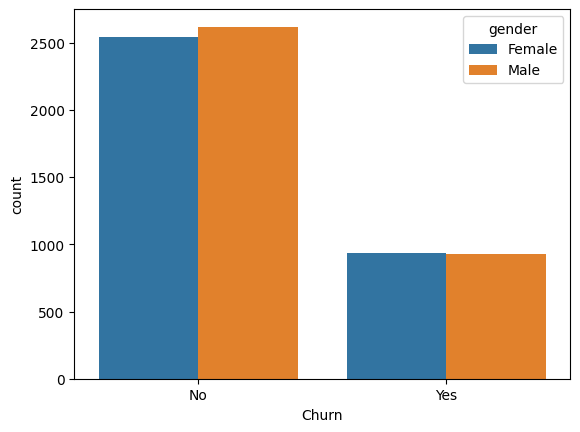

In [13]:
sns.countplot(x ='Churn', hue = 'gender', data = df_clean)

<Axes: xlabel='Churn', ylabel='Count'>

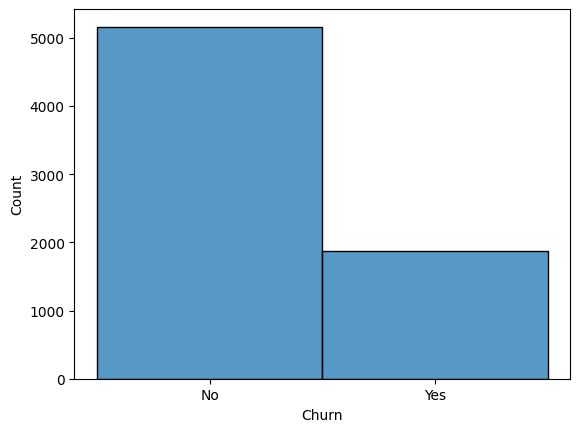

In [14]:
sns.histplot(df_clean['Churn'], bins = 20)

Roughly 5,000+ customers stay (0.0), while around 1,800–2,000 customers leave (1.0).


In [15]:
df_clean['gender'].value_counts(normalize = True)

gender
Male      0.504693
Female    0.495307
Name: proportion, dtype: float64

In [16]:
map_values = {'Yes':1,'No':0}

df_clean['Churn'] = df_clean['Churn'].map(map_values).astype(int)

In [17]:
# Selecting numerical columns from the dataset
num_cols = df_clean.select_dtypes(include=['int','float'])

In [18]:
num_cols.columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn'], dtype='object')

In [19]:
# Selecting categorical columns from the dataset
cat_cols = df_clean.select_dtypes(include =['object'])

In [20]:
cat_cols.columns

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

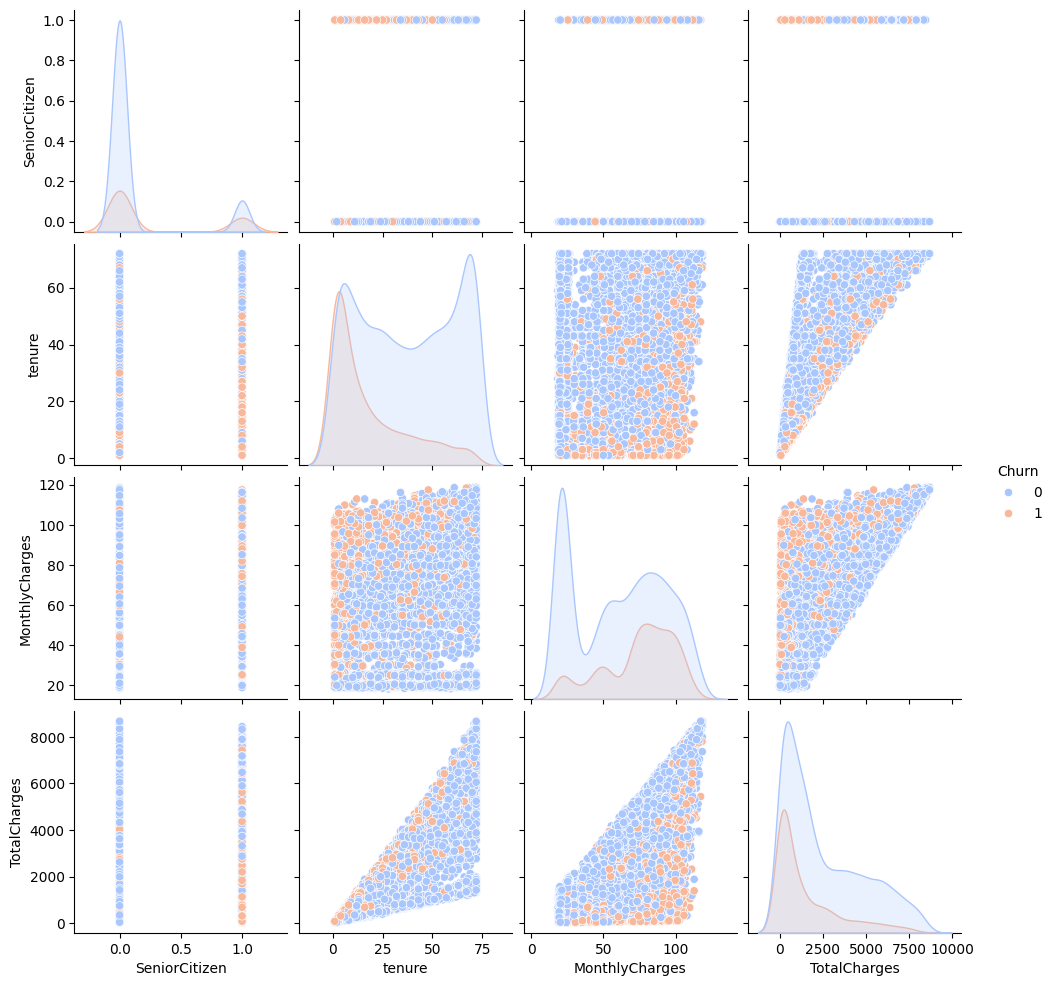

In [21]:
sns.pairplot(num_cols, hue = 'Churn', palette = 'coolwarm')

<Axes: >

<Figure size 1000x600 with 0 Axes>

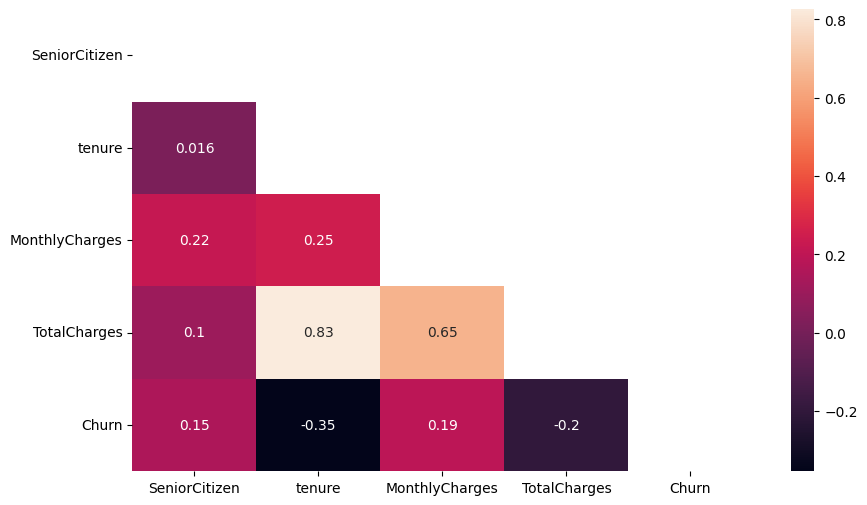

In [22]:
num_corr = num_cols.corr()
plt.figure(figsize=(10,6))
mask = np.triu(num_corr)
plt.figure(figsize=(10,6))
sns.heatmap(num_corr,annot = True, mask = mask)

- There exist a strong positive correlation coefficient between TotalCharges and tenure, which simply means that, the longer a customer stays, the more money they inevitably spend over time.
- Also, there exist a strong positive correlation between TotalCharges and MonthlyCharges which could mmean that, customers with expensive monthly packages (like premium TV or multiple phone lines) pile up larger lifetime bills much faster than those on cheap plans.
- Tenure has a slightly negatively weak correlation coefficient with Churn which could mean that, the longer a client stays, the less likely they are to leave.
- A low negative correlation of -0.2 and Churn,could mean that ustomers who have spent a lot of money in total are slightly less likely to leave, but this is usually just because they have high tenure.

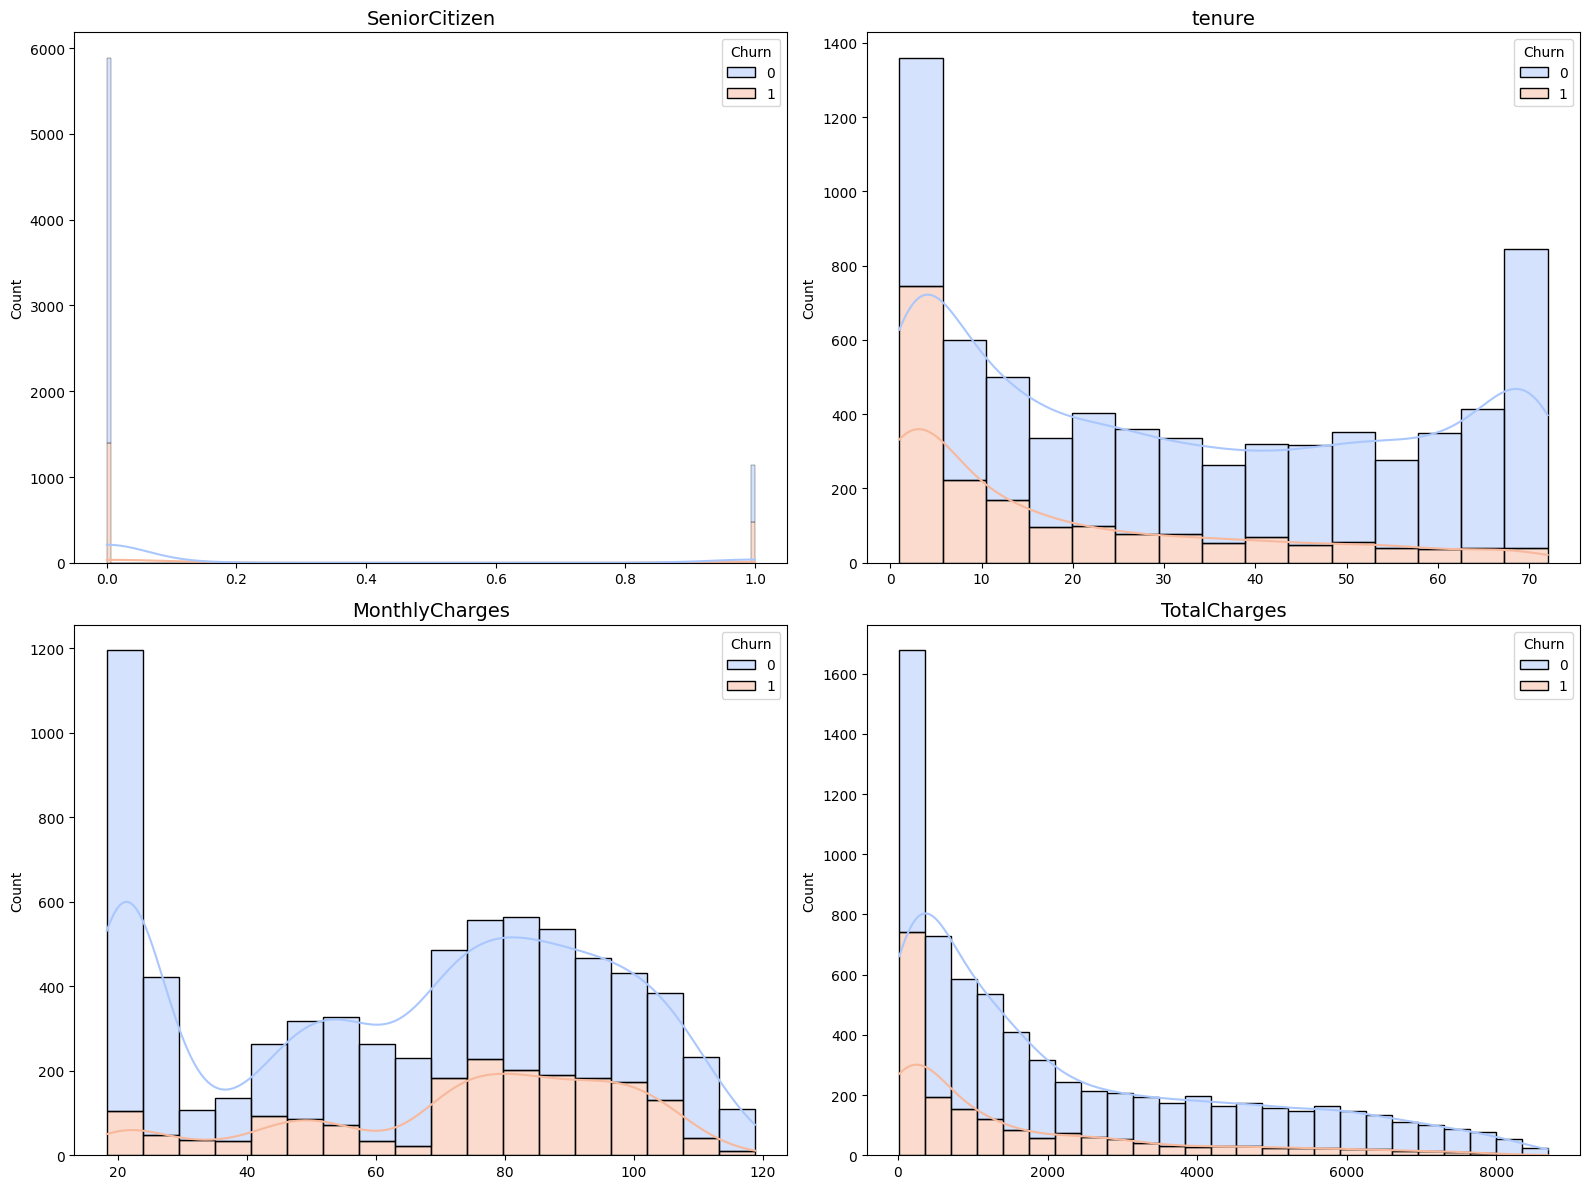

In [23]:
# Set up the plotting grid (2 rows, 2 columns for the continuous variables)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes_flat = axes.flatten()

# Loop through and create the overlaid histograms
for i, col in enumerate(num_cols.columns.drop('Churn')):
    sns.histplot(
        data=df_clean,
        x=col,
        hue='Churn',
        multiple='stack',
        palette='coolwarm',
        ax=axes_flat[i],
        kde=True
    )
    axes_flat[i].set_title(col, fontsize=14)
    axes_flat[i].set_xlabel('')
    axes_flat[i].set_ylabel('Count')

# 3. Clean up the layout
plt.tight_layout()
plt.show()


- **SeniorCitizen :**
This shows our customer base is heavily skewed toward younger demographics.
Only a small fraction (around 1,000+ customers) are classified as senior citizens (1.0), while the vast majority (nearly 6,000 customers) are not (0.0).

- **Tenure :**
The tenure distribution is strongly U-shaped, with large concentrations of customers at both very low and very high tenure values meaning customers either churn early in their lifecycle or remain customers for many years, suggesting that early customer retention initiatives could have a significant impact on reducing churn.

- **MonthlyCharges :**
Most customers are concentrated in either low-cost or premium pricing tiers meaning high-value customers represent a substantial portion of revenue and should be monitored closely for churn risk.

- **TotalCharges :**
This follows a right-skewed exponential decay pattern. Most customers have very low lifetime spending (under $2,000) because so many drop out early (as seen in the tenure graph). Only a tiny handful of users reach lifetime values between $6,000 and $8,000.


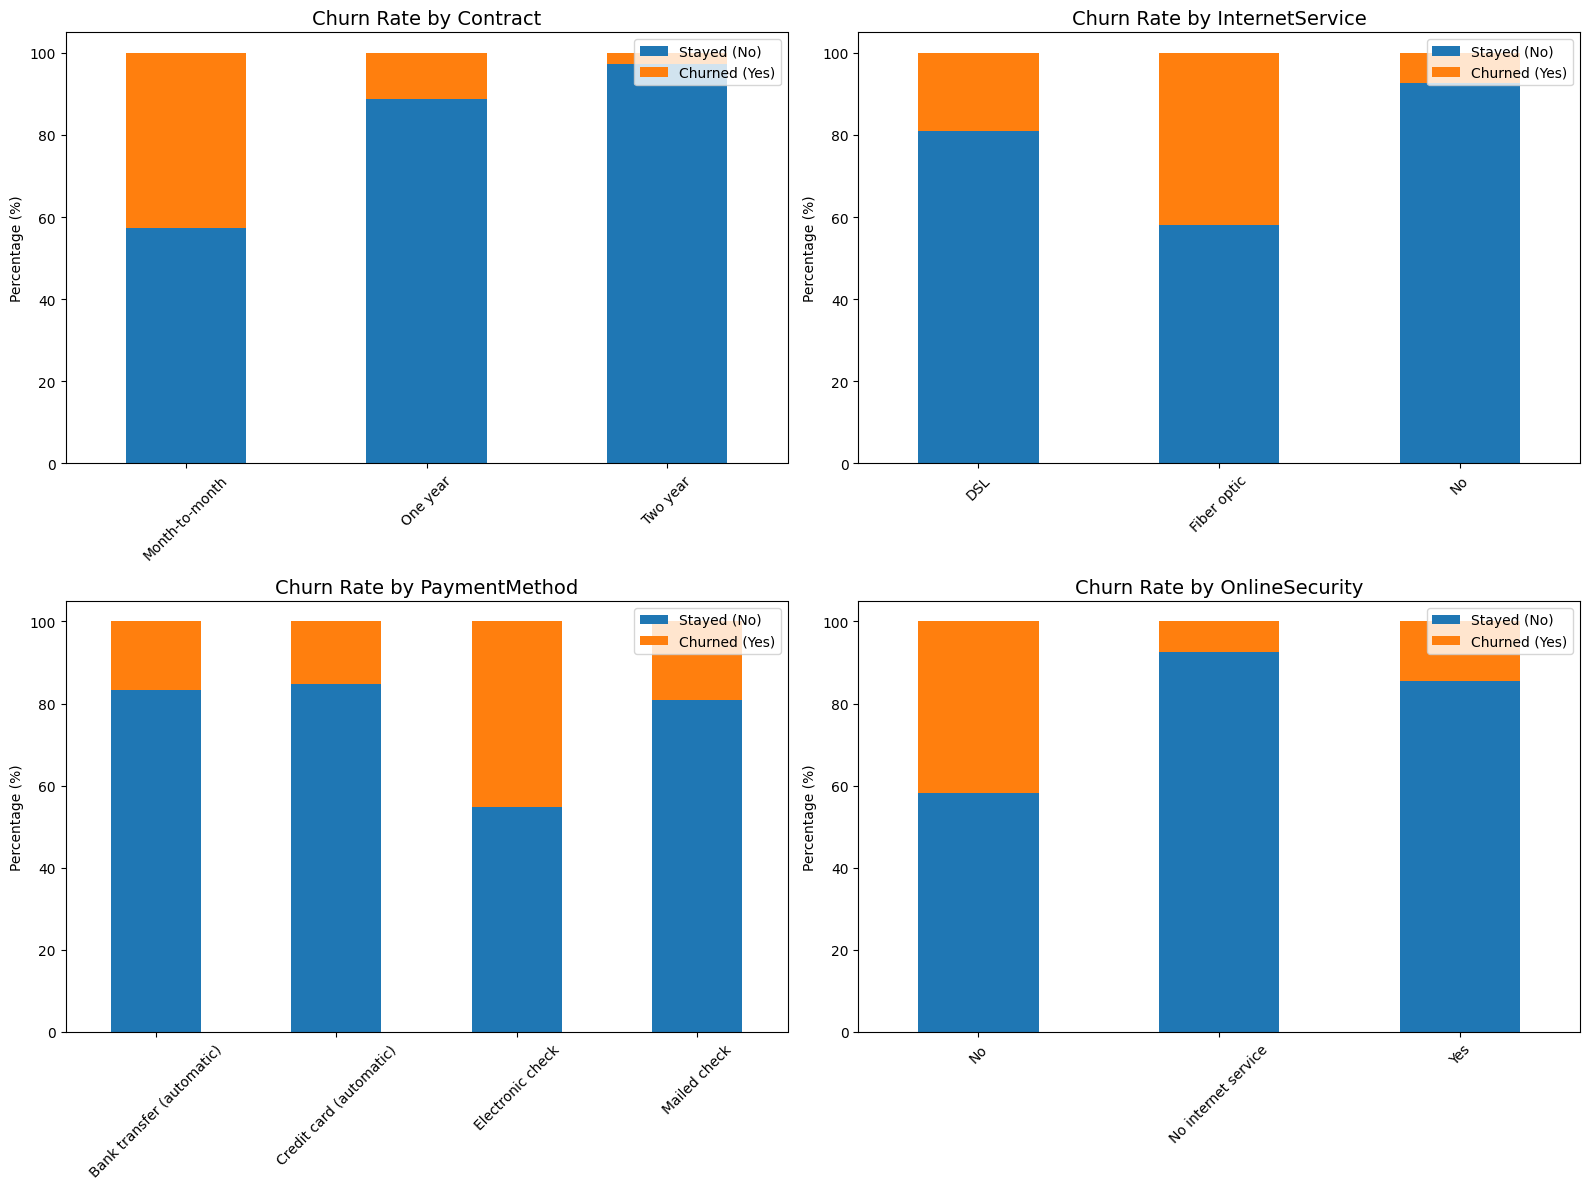

In [24]:
# List of key categorical columns to test
cats = ['Contract', 'InternetService', 'PaymentMethod', 'OnlineSecurity']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes_flat = axes.flatten()

for i, col in enumerate(cats):
    # Calculate percentages instead of raw counts
    df_pct = df.groupby(col)['Churn'].value_counts(normalize=True).unstack() * 100
    
    # Plot stacked bar chart
    df_pct.plot(kind='bar', stacked=True, ax=axes_flat[i])
    
    axes_flat[i].set_title(f'Churn Rate by {col}', fontsize=14)
    axes_flat[i].set_ylabel('Percentage (%)')
    axes_flat[i].set_xlabel('')
    axes_flat[i].tick_params(axis='x', rotation=45)
    axes_flat[i].legend(['Stayed (No)', 'Churned (Yes)'], loc='upper right')

plt.tight_layout()
plt.show()


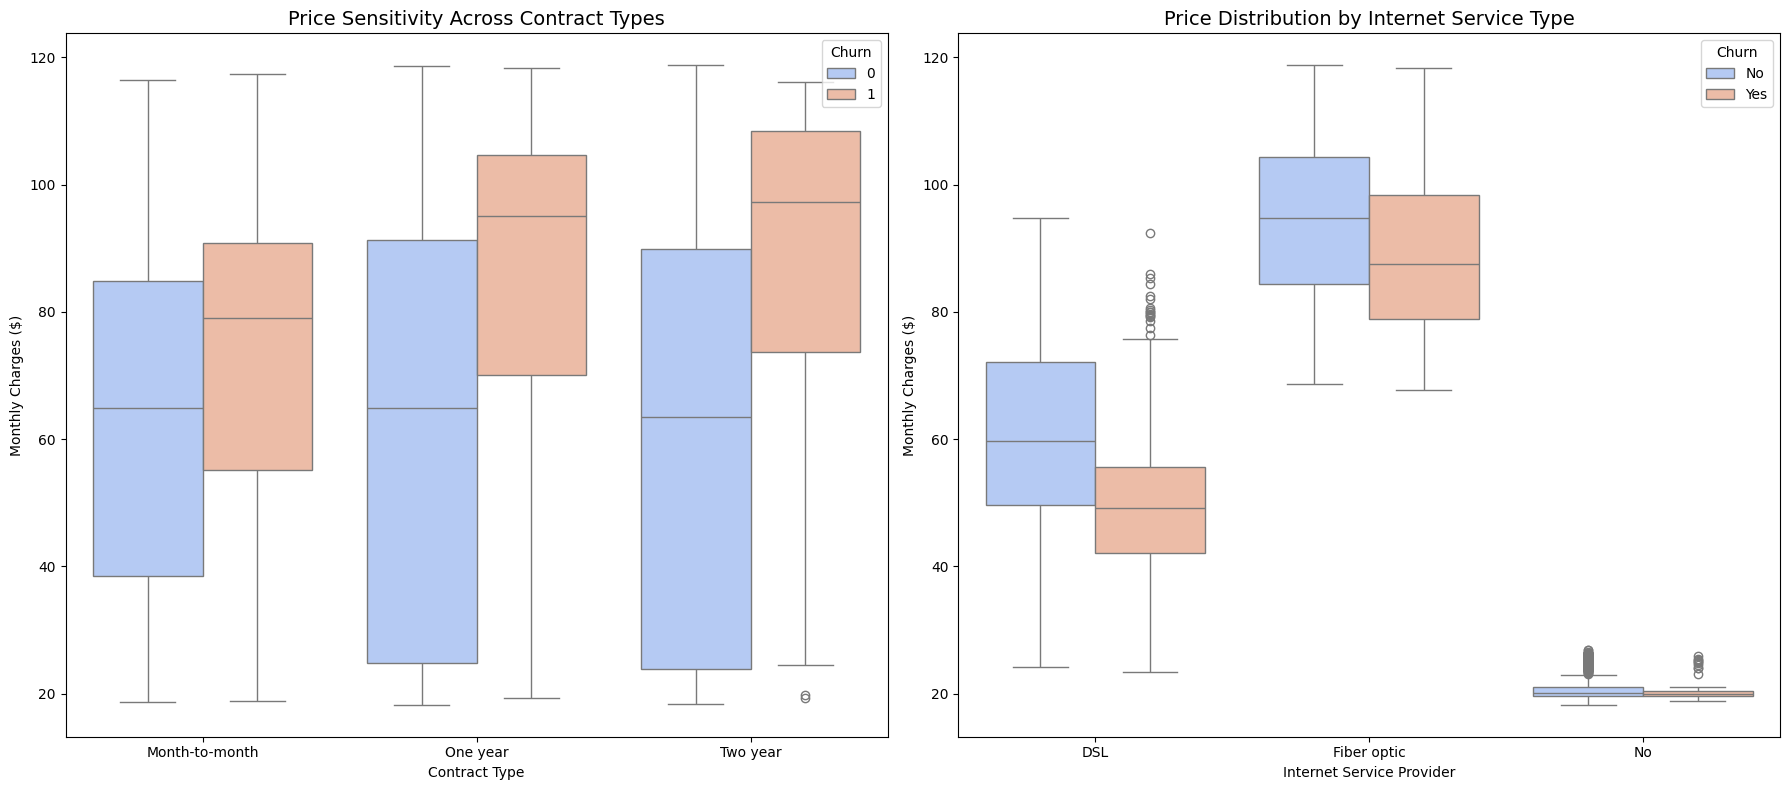

In [25]:
#  Set up a 1-row, 2-column plotting area
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Plot 1: Contract vs Monthly Charges (Split by Churn)
sns.boxplot(
    data=df_clean, 
    x='Contract', 
    y='MonthlyCharges', 
    hue='Churn', 
    palette='coolwarm',
    ax=axes[0]
)
axes[0].set_title('Price Sensitivity Across Contract Types', fontsize=14)
axes[0].set_xlabel('Contract Type')
axes[0].set_ylabel('Monthly Charges ($)')

# Plot 2: Internet Service vs Monthly Charges (Split by Churn)
sns.boxplot(
    data=df, 
    x='InternetService', 
    y='MonthlyCharges', 
    hue='Churn', 
    palette='coolwarm',
    ax=axes[1]
)
axes[1].set_title('Price Distribution by Internet Service Type', fontsize=14)
axes[1].set_xlabel('Internet Service Provider')
axes[1].set_ylabel('Monthly Charges ($)')

plt.tight_layout()
plt.show()


1. **Price Sensitivity Across Contract Types:** As contract length increases (from Month-to-month to Two-year), the price gap between loyal customers and churning customers widens dramatically. For Two-year contracts, the median monthly charge for those who churned is extremely high—approaching $100—compared to around $63 for those who stayed. A long-term contract will keep a customer loyal even at moderate prices, but once their monthly bill aggressively creeps toward that $100 threshold, the legal/financial friction of breaking a contract no longer stops them. 
2. **Price Distribution by Internet Service Type:** For DSL, the customers who churn actually pay less than those who stay. But for Fiber optic, the prices are incredibly high across the board (medians between $85 and $95), with a massive chunk of both churners and retainers paying maximum tier prices. Fiber optic is aggressively expensive. Customers aren't necessarily leaving Fiber because the service is bad; they are leaving because the price floor starts incredibly high (around $70–$80) and escalates. 
3. Customers with "No" internet service have a completely compressed, flat distribution tightly locked around $20 per month.Because a $20 bill is already at the absolute rock-bottom price floor for telecom services, price is likely not the reason these customers churn. If a phone-only customer leaves, it is almost never because of a "bill shock." Instead, it is driven by non-financial life events such as moving to a new area, passing away, or completely abandoning landline tech for a mobile-only lifestyle.

Partial Conclusion:
Our churn problem is completely driven by price ceilings. On short-term month-to-month plans, customers bounce quickly if they feel unsupported. However, on premium tiers like Fiber Optic or long-term contracts, loyalty is strong until the monthly bill approaches $100. At that point, the contract safety net fails, and our highest-paying customers walk out the door.

## Feature Engineering

In [26]:
# Average Monthly revenue
df_clean['avg_monthly_spend'] = (df_clean['MonthlyCharges'] / (df_clean['tenure'] + 1))

In [27]:
# Customer lifetime Value
df_clean['customer_lifetime_value'] = (df_clean['MonthlyCharges'] *df_clean['tenure'])

## Model Selection and Evaluation

In [28]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, precision_score, recall_score,f1_score
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier

In [29]:
# Create Transformers
numeric_transformer = Pipeline(steps =[
    ('num_imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps =[
    ('cat_imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

In [30]:
num_feats = df_clean.select_dtypes(include = ['float', 'int']).columns.drop('Churn')
cat_feats = df_clean.select_dtypes(include = ['object']).columns

In [31]:
# Combining the above transfomers into a single preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_feats),
        ('cat', categorical_transformer, cat_feats)
    ]
)

In [32]:
X = df_clean.drop('Churn', axis = 1)
y = df_clean['Churn']

In [33]:
X.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'avg_monthly_spend',
       'customer_lifetime_value'],
      dtype='object')

In [34]:
# Splitting the data into training and testing set
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.3, random_state=101)

In [35]:
models = {
    "Logistic Regression":LogisticRegression(max_iter=1000),

    "Random Forest":RandomForestClassifier(),

    "XGBoost":XGBClassifier()
}

In [36]:
results = []

best_model = None
best_auc = 0

for name, model in models.items():

    pipeline = Pipeline(
        steps=[
            ("preprocessor",preprocessor),
            ("model",model)
        ]
    )

    pipeline.fit(X_train,y_train)

    preds = pipeline.predict(X_test)

    probs = pipeline.predict_proba(X_test)[:,1]

    auc = roc_auc_score(y_test,probs)

    results.append({
        "model": name,
        "accuracy":
            accuracy_score(
                y_test,
                preds
            ),
        "precision":
            precision_score(
                y_test,
                preds
            ),
        "recall":
            recall_score(
                y_test,
                preds
            ),
        "f1":
            f1_score(
                y_test,
                preds
            ),
        "roc_auc":
            auc
    })

    if auc > best_auc:
        best_auc = auc
        best_model = pipeline

In [37]:
results_df = pd.DataFrame(results)

print(results_df.sort_values("roc_auc", ascending=False))

                 model  accuracy  precision    recall        f1   roc_auc
0  Logistic Regression  0.815166   0.662791  0.537736  0.593750  0.840648
2              XGBoost  0.790047   0.592357  0.526415  0.557443  0.823190
1        Random Forest  0.792891   0.604027  0.509434  0.552712  0.822594


In [38]:
best_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

**Hyperparameter Tuning**

In [39]:
xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            XGBClassifier(
                random_state=42,
                eval_metric="logloss"
            )
        )
    ]
)

In [40]:
param_grid = {

    "model__n_estimators":
        [100, 200, 300, 500],

    "model__max_depth":
        [3, 4, 5, 6, 8],

    "model__learning_rate":
        [0.01, 0.03, 0.05, 0.1],

    "model__subsample":
        [0.7, 0.8, 0.9, 1.0],

    "model__colsample_bytree":
        [0.7, 0.8, 0.9, 1.0],

    "model__min_child_weight":
        [1, 3, 5],

    "model__gamma":
        [0, 0.1, 0.3]
}

In [41]:
search = RandomizedSearchCV(
    estimator=xgb_pipeline,

    param_distributions=param_grid,

    n_iter=30,

    scoring="roc_auc",

    cv=5,

    verbose=2,

    random_state=42,

    n_jobs=-1
)

In [42]:
search.fit(X_train,y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__colsample_bytree': [0.7, 0.8, ...], 'model__gamma': [0, 0.1, ...], 'model__learning_rate': [0.01, 0.03, ...], 'model__max_depth': [3, 4, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strate

In [43]:
search_preds = search.predict(X_test)

In [44]:
print(confusion_matrix(y_test, search_preds))
print('\n')
print(classification_report(y_test, search_preds))

[[1431  149]
 [ 242  288]]


              precision    recall  f1-score   support

           0       0.86      0.91      0.88      1580
           1       0.66      0.54      0.60       530

    accuracy                           0.81      2110
   macro avg       0.76      0.72      0.74      2110
weighted avg       0.81      0.81      0.81      2110



In [45]:
print(confusion_matrix(y_test, best_model.predict(X_test)))
print('\n')
print(classification_report(y_test, best_model.predict(X_test)))

[[1435  145]
 [ 245  285]]


              precision    recall  f1-score   support

           0       0.85      0.91      0.88      1580
           1       0.66      0.54      0.59       530

    accuracy                           0.82      2110
   macro avg       0.76      0.72      0.74      2110
weighted avg       0.81      0.82      0.81      2110



## Model Selection

Three classification models were evaluated: Logistic Regression, Random Forest, and XGBoost. Performance was assessed using Accuracy, Precision, Recall, F1-Score, and ROC-AUC.

Although XGBoost was further optimized using RandomizedSearchCV, it did not demonstrate a meaningful improvement over Logistic Regression. Both models produced nearly identical classification performance, while Logistic Regression achieved the highest ROC-AUC during baseline evaluation.

Following the engineering principle of Occam's Razor, the simpler model was selected. Logistic Regression offers superior interpretability, faster training and inference, lower maintenance requirements, and easier communication of business insights without sacrificing predictive performance.

Therefore, Logistic Regression was chosen as the production model for customer churn prediction.

In [46]:
feature_names = best_model.named_steps[
    "preprocessor"
].get_feature_names_out()

coefficients = best_model.named_steps[
    "model"
].coef_[0]

In [47]:
importance_df = pd.DataFrame({"feature": feature_names,"coefficient": coefficients})

importance_df["abs_coef"] = (importance_df["coefficient"].abs())

importance_df.sort_values("abs_coef",ascending=False).head(20)

,feature,coefficient,abs_coef
40,cat__Contract_Two year,-0.974838,0.974838
1,num__tenure,-0.861975,0.861975
38,cat__Contract_Month-to-month,0.759052,0.759052
17,cat__InternetService_DSL,-0.576950,0.576950
18,cat__InternetService_Fiber optic,0.525598,0.525598
2,num__MonthlyCharges,-0.440598,0.440598
4,num__avg_monthly_spend,0.404280,0.404280
5,num__customer_lifetime_value,0.357879,0.357879
14,cat__MultipleLines_No,-0.296537,0.296537
41,cat__PaperlessBilling_No,-0.280425,0.280425


<Axes: title={'center': 'Feature Importance - Top Churn Drivers'}, xlabel='coefficient', ylabel='feature'>

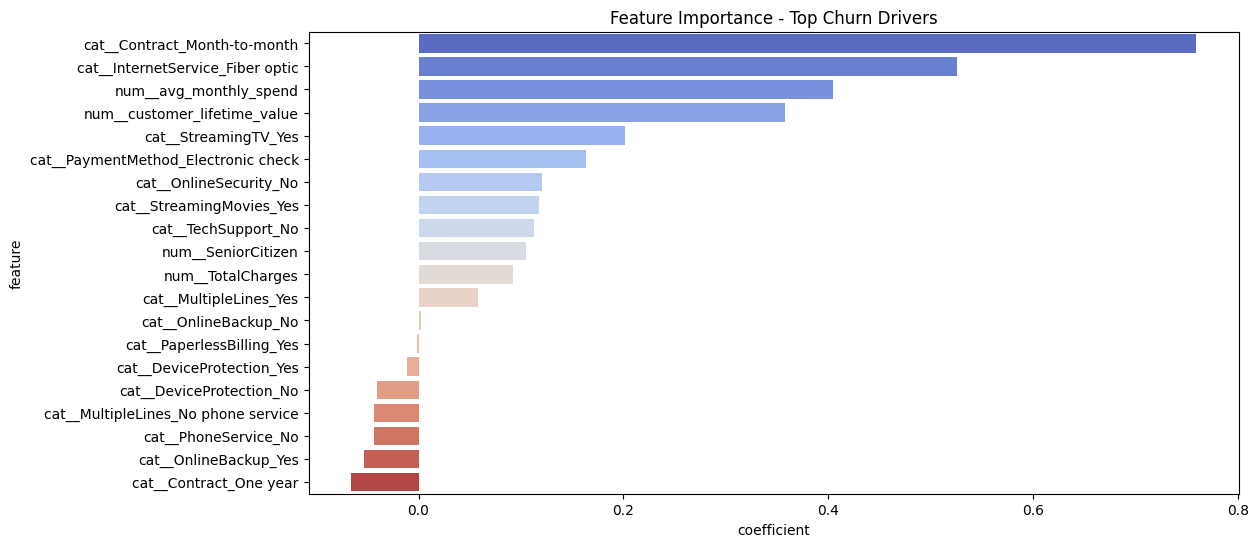

In [48]:
# Model Feature Importance
plt.figure(figsize=(12,6))
plt.title('Feature Importance - Top Churn Drivers')
sns.barplot(data = importance_df.sort_values(by ='coefficient', ascending = False).head(20), x ='coefficient',y = 'feature', palette = 'coolwarm', orient ='h')

**KPI's for Dashboard Visualization**

In [49]:
probs = best_model.predict_proba(X_test)[:,1]

risk_df = X_test.copy()

risk_df["actual_churn"] = y_test

risk_df["churn_probability"] = probs

risk_df = risk_df.sort_values("churn_probability",ascending=False)

risk_df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,avg_monthly_spend,customer_lifetime_value,actual_churn,churn_probability
customerID,,,,,,,,,,,,,,,,,,,,,
5419-JPRRN,Male,0,No,No,1,Yes,Yes,Fiber optic,No,No,...,Yes,Month-to-month,Yes,Electronic check,101.45,101.45,50.725,101.45,1,0.958776
3068-OMWZA,Male,1,No,No,1,Yes,Yes,Fiber optic,No,No,...,No,Month-to-month,Yes,Electronic check,88.80,88.80,44.400,88.80,1,0.953808
3988-RQIXO,Female,1,No,No,1,Yes,No,Fiber optic,No,No,...,Yes,Month-to-month,Yes,Electronic check,91.30,91.30,45.650,91.30,1,0.950935
1415-YFWLT,Female,1,No,No,1,Yes,No,Fiber optic,No,No,...,Yes,Month-to-month,Yes,Electronic check,89.30,89.30,44.650,89.30,1,0.950034
6521-YYTYI,Male,0,No,Yes,1,Yes,Yes,Fiber optic,No,No,...,Yes,Month-to-month,Yes,Electronic check,93.30,93.30,46.650,93.30,1,0.949266


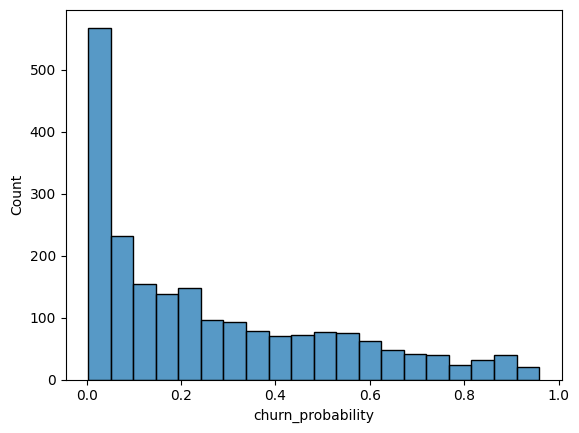

In [50]:
sns.histplot(risk_df["churn_probability"],bins=20)
plt.show()

In [51]:
def assign_risk(score):

    if score >= 0.60:
        return "High"

    elif score >= 0.30:
        return "Medium"

    else:
        return "Low"

In [52]:
risk_df["risk_tier"] = risk_df["churn_probability"].apply(assign_risk)

In [53]:
risk_df["monthly_revenue_at_risk"] = (risk_df["MonthlyCharges"]* risk_df["churn_probability"])
risk_df["monthly_revenue_at_risk"].sum()

np.float64(41116.141702863075)

In [54]:
print(risk_df["risk_tier"].value_counts())

print(risk_df["monthly_revenue_at_risk"].sum())

risk_tier
Low       1357
Medium     479
High       274
Name: count, dtype: int64
41116.141702863075


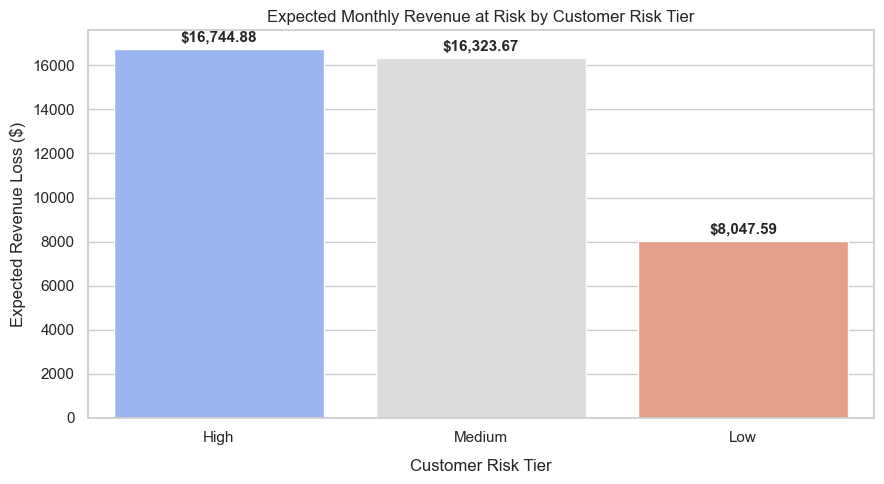

Total Blended Monthly Revenue at Risk: $41,116.14
Annualized Portfolio Exposure: $493,393.70


In [55]:
tier_summary = risk_df.groupby("risk_tier")["monthly_revenue_at_risk"].sum().reset_index()

# Ensure the tiers plot in a logical order
tier_order = ["High", "Medium", "Low"]
tier_summary['risk_tier'] = pd.Categorical(tier_summary['risk_tier'], categories=tier_order, ordered=True)
tier_summary = tier_summary.sort_values("risk_tier")

# Create bar plot
plt.figure(figsize=(9, 5))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    x="risk_tier", 
    y="monthly_revenue_at_risk", 
    data=tier_summary, 
    palette="coolwarm", 
    hue="risk_tier",
    legend=False
)

# Format the plot labels and titles
plt.title("Expected Monthly Revenue at Risk by Customer Risk Tier")
plt.xlabel("Customer Risk Tier", fontsize=12, labelpad=10)
plt.ylabel("Expected Revenue Loss ($)")

# Adding dollar values on top of each bar
for p in ax.patches:
    ax.annotate(
        f"${p.get_height():,.2f}", 
        (p.get_x() + p.get_width() / 2., p.get_height()), 
        ha='center', 
        va='center', 
        xytext=(0, 8), 
        textcoords='offset points', 
        fontsize=11, 
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

total_expected_loss = risk_df["monthly_revenue_at_risk"].sum()
print(f"Total Blended Monthly Revenue at Risk: ${total_expected_loss:,.2f}")
print(f"Annualized Portfolio Exposure: ${total_expected_loss * 12:,.2f}")

In [56]:
all_probs = best_model.predict_proba(X)[:,1]

dashboard_df = X.copy()

dashboard_df["churn_probability"] = all_probs

In [57]:
dashboard_df["risk_level"] = (dashboard_df["churn_probability"].apply(assign_risk))

In [58]:
dashboard_df["monthly_revenue_at_risk"] = (dashboard_df["MonthlyCharges"]* dashboard_df["churn_probability"])

In [59]:
def tenure_labels(months):
    if months <= 12:
        return 'First-Year Accounts'
    elif months <= 24:
        return 'Second-Year Accounts'
    elif months <=48:
        return 'Established Accounts'
    else:
        return 'Loyal Accounts'
    
dashboard_df['tenure_group'] = dashboard_df['tenure'].apply(tenure_labels)

In [60]:
dashboard_df = dashboard_df.reset_index()

In [61]:
dashboard_df.to_csv('D:\Projects\Telco Dataset\dashboard_data.csv')

OSError: Cannot save file into a non-existent directory: 'D:\Projects\Telco Dataset'

In [ ]:
importance_df.to_csv( "feature_importance.csv", index=False)

### Saving the Model

In [ ]:
import joblib
joblib.dump(best_model,'telco_churn_probability_estimator_lr.joblib')

['telco_churn_probability_estimator_lr.joblib']

In [ ]:
dashboard_df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'avg_monthly_spend',
       'customer_lifetime_value', 'churn_probability', 'risk_level',
       'monthly_revenue_at_risk', 'tenure_group'],
      dtype='object')

### Key Findings

- Month-to-month contracts are strongly associated with churn.
- Customers with short tenure exhibit the highest churn risk.
- Fiber optic customers experience elevated churn rates.
- Long-term contracts significantly improve retention.

### Recommendations

- Target new customers during their first 12 months.
- Offer incentives to migrate customers from month-to-month to annual contracts.
- Monitor high-value fiber customers for early churn indicators.
- Prioritize retention campaigns for customers with high predicted churn probabilities.